In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from datetime import datetime
from pathlib import Path
from PIL import Image

In [2]:
# Mount Google Drive only when running on Colab; on a local machine this is a no-op.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False
    print('Not running on Colab — skipping drive.mount.')

Not running on Colab — skipping drive.mount.


In [3]:
# Set this to your dataset root directory.
# Expected structure: DATA_DIR / <emperor_folder> / side_a / *.jpg
# (e.g. DATA_DIR / 01_Augustus / side_a / *.jpg)
if ON_COLAB:
    DATA_DIR = r'/content/drive/MyDrive/coin_dataset'
else:
    DATA_DIR = r'/home/david/coin/FOR_TRAINNING'

In [4]:
# Collect filepaths from each emperor's side_a folder
image_dir = Path(DATA_DIR)
filepaths = sorted(image_dir.glob('*/side_a/*.jpg'))

# Extract label from parent emperor folder name, stripping the numeric prefix (e.g. '01_Augustus' -> 'Augustus')
def extract_label(path):
    emperor_folder = path.parent.parent.name  # e.g. '01_Augustus'
    return re.sub(r'^\d+_', '', emperor_folder)  # -> 'Augustus'

raw_labels = [extract_label(p) for p in filepaths]

# Build label encoder dynamically from sorted unique labels
unique_labels = sorted(set(raw_labels))
label_encoder = {name: idx for idx, name in enumerate(unique_labels)}
num_classes = len(label_encoder)

print(f'Found {num_classes} classes:')
for name, idx in label_encoder.items():
    print(f'  {idx:2d}: {name}')

filepaths_series = pd.Series([str(p) for p in filepaths], name='Filepath')
labels_series = pd.Series([label_encoder[l] for l in raw_labels], name='Label')

image_df = pd.concat([filepaths_series, labels_series], axis=1)
print(f'\nTotal images: {len(image_df)}')

Found 52 classes:
   0: AEMILIAN
   1: ANTONINUS PIUS
   2: AUGUSTUS
   3: AURELIAN
   4: BALBINUS
   5: CALIGULA
   6: CARACALLA
   7: CARINUS
   8: CARUS
   9: CLAUDIUS
  10: CLAUDIUS GOTHICUS
  11: COMMODUS
  12: CONSTANTIUS I
  13: DIDIUS JULIANUS
  14: DIOCLETIAN
  15: DOMITIAN
  16: ELAGABALUS
  17: FLORIANUS
  18: GALBA
  19: GALERIUS
  20: GALLIENUS
  21: GETA
  22: GORDIAN I
  23: GORDIAN II
  24: GORDIAN III
  25: HADRIAN
  26: LUCIUS VERUS
  27: MACRINUS
  28: MARCUS AURELIUS
  29: MAXIMIAN
  30: MAXIMINUS THRAX
  31: NERO
  32: NERVA
  33: NUMERIAN
  34: OTHO
  35: PERTINAX
  36: PHILIP THE ARAB
  37: PROBUS
  38: PUPIENUS
  39: QUINTILLUS
  40: SEPTIMUS SEVERUS
  41: SEVERUS ALEXANDER
  42: SEVERUS II
  43: TACITUS
  44: TIBERIUS
  45: TITUS
  46: TRAJAN
  47: TRAJAN DECIUS
  48: TRBONIANUS GALLUS
  49: VALERIAN
  50: VESPASIAN
  51: VITELLIUS

Total images: 62364


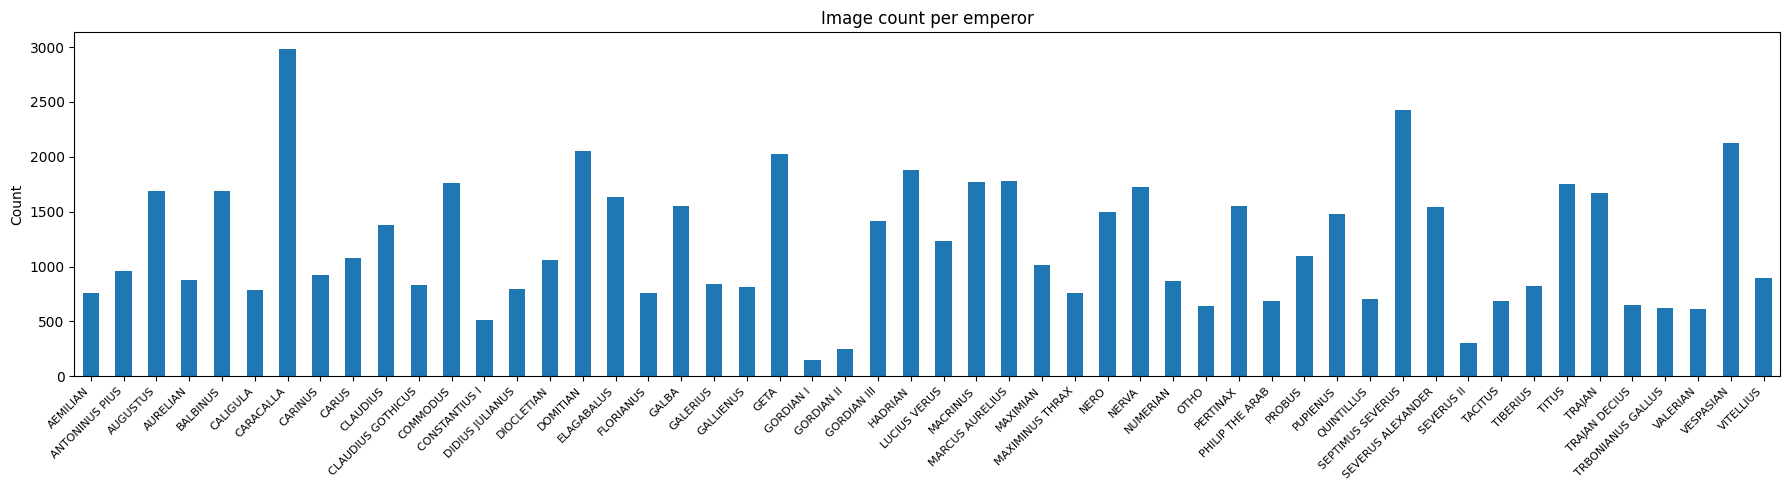

In [5]:
# Inverse map for readable labels on plots
idx_to_label = {v: k for k, v in label_encoder.items()}

plt.figure(figsize=(18, 5))
count_data = image_df['Label'].value_counts().sort_index()
ax = count_data.plot(kind='bar')
ax.set_xticklabels([idx_to_label[i] for i in count_data.index], rotation=45, ha='right', fontsize=8)
ax.set_title('Image count per emperor')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [6]:
# Simple dataset that loads images and normalises to [0,1] (RADIO handles mean/std internally)
class CoinDataset(Dataset):
    def __init__(self, filepaths, labels, resolution=256):
        self.filepaths = filepaths.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.resolution = resolution

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert('RGB')
        img = img.resize((self.resolution, self.resolution), Image.BILINEAR)
        img = torch.from_numpy(np.array(img)).permute(2, 0, 1).float().div_(255.0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

In [7]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
# C-RADIO is loaded inside the next cell, only when there is unprocessed
# work to do, so re-running after a crash does not waste time on the backbone.

Device: cuda:0


In [8]:
# Chunked, resumable feature extraction.
# The dataset is split into NUM_CHUNKS pieces. Each chunk is saved to disk as
# soon as it is computed, so a crash / kernel interrupt loses at most one chunk.
# Re-running the cell skips chunks already on disk and resumes from the next one.
# Once every chunk exists, they are concatenated into a single embeddings file.
NUM_CHUNKS = 10

embeddings_root  = Path(DATA_DIR)
final_embeddings_path = embeddings_root / 'cradio_v4_embeddings.pt'
chunks_dir = embeddings_root / 'cradio_v4_embeddings_chunks'
chunks_dir.mkdir(parents=True, exist_ok=True)

def chunk_ranges(n_total, n_chunks):
    edges = np.linspace(0, n_total, n_chunks + 1, dtype=int)
    return [(i, int(edges[i]), int(edges[i + 1])) for i in range(n_chunks)]

@torch.no_grad()
def extract_chunk(filepaths, labels, radio_model, device, batch_size=8, resolution=256):
    ds = CoinDataset(filepaths, labels, resolution=resolution)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)
    feats, labs = [], []
    for i, (imgs, l) in enumerate(loader):
        imgs = imgs.to(device)
        with torch.autocast('cuda', dtype=torch.bfloat16):
            summary, _ = radio_model(imgs)
        feats.append(summary.float().cpu())
        labs.append(l)
        if (i + 1) % 100 == 0:
            print(f'    batch {i + 1}/{len(loader)}')
    return torch.cat(feats), torch.cat(labs)

if final_embeddings_path.exists():
    print(f'Final embeddings already exist at {final_embeddings_path} — loading.')
    saved = torch.load(final_embeddings_path)
    all_feats, all_labs = saved['features'], saved['labels']
else:
    ranges = chunk_ranges(len(image_df), NUM_CHUNKS)
    missing = [r for r in ranges if not (chunks_dir / f'chunk_{r[0]:02d}.pt').exists()]

    if missing:
        done = NUM_CHUNKS - len(missing)
        print(f'{done}/{NUM_CHUNKS} chunks already done. Loading C-RADIO v4-H to process the remaining {len(missing)}...')
        radio_model = torch.hub.load('NVlabs/RADIO', 'radio_model',
                                     version='c-radio_v4-h', progress=True)
        radio_model = radio_model.to(device).eval()
        for p in radio_model.parameters():
            p.requires_grad = False

        for idx, start, end in missing:
            chunk_path = chunks_dir / f'chunk_{idx:02d}.pt'
            print(f'Chunk {idx + 1}/{NUM_CHUNKS}  rows {start}:{end}  ({end - start} images)')
            t0 = datetime.now()
            sub_fp = image_df.Filepath.iloc[start:end]
            sub_lb = image_df.Label.iloc[start:end]
            feats, labs = extract_chunk(sub_fp, sub_lb, radio_model, device)
            torch.save({'features': feats, 'labels': labs}, chunk_path)
            print(f'  saved {chunk_path.name} in {datetime.now() - t0}')

        del radio_model
        torch.cuda.empty_cache()
    else:
        print('All chunks already on disk — skipping backbone load.')

    print('Concatenating chunks into final embeddings file...')
    feats_list, labs_list = [], []
    for idx, _, _ in ranges:
        d = torch.load(chunks_dir / f'chunk_{idx:02d}.pt')
        feats_list.append(d['features'])
        labs_list.append(d['labels'])
    all_feats = torch.cat(feats_list)
    all_labs  = torch.cat(labs_list)
    torch.save({'features': all_feats, 'labels': all_labs}, final_embeddings_path)
    print(f'Saved combined embeddings to {final_embeddings_path}')

print(f'Embeddings: {all_feats.shape}')

0/10 chunks already done. Loading C-RADIO v4-H to process the remaining 10...


/home/david/.local/lib/python3.10/site-packages/torch/hub.py:294: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(
Downloading: "https://github.com/NVlabs/RADIO/zipball/main" to /home/david/.cache/torch/hub/main.zip
Downloading: "https://huggingface.co/nvidia/C-RADIOv4-H/resolve/main/c-radio_v4-h_half.pth.tar?download=true" to /home/david/.cache/torch/hub/checkpoints/c-radio_v4-h_half.pth.tar
100%|██████████| 1.57G/1.57G [04:27<00:00, 6.29MB/s]
/home/david/

Chunk 1/10  rows 0:6236  (6236 images)
    batch 100/780
    batch 200/780
    batch 300/780
    batch 400/780
    batch 500/780
    batch 600/780
    batch 700/780
  saved chunk_00.pt in 0:01:05.242519
Chunk 2/10  rows 6236:12472  (6236 images)
    batch 100/780
    batch 200/780
    batch 300/780
    batch 400/780
    batch 500/780
    batch 600/780
    batch 700/780
  saved chunk_01.pt in 0:01:07.317883
Chunk 3/10  rows 12472:18709  (6237 images)
    batch 100/780
    batch 200/780
    batch 300/780
    batch 400/780
    batch 500/780
    batch 600/780
    batch 700/780
  saved chunk_02.pt in 0:01:07.804967
Chunk 4/10  rows 18709:24945  (6236 images)
    batch 100/780
    batch 200/780
    batch 300/780
    batch 400/780
    batch 500/780
    batch 600/780
    batch 700/780
  saved chunk_03.pt in 0:01:05.895153
Chunk 5/10  rows 24945:31182  (6237 images)
    batch 100/780
    batch 200/780
    batch 300/780
    batch 400/780
    batch 500/780
    batch 600/780
    batch 700/780
  sa

In [9]:
# Split embeddings into train / val / test
train_feats, test_feats, train_labs, test_labs = train_test_split(
    all_feats, all_labs, test_size=0.2, shuffle=True, stratify=all_labs, random_state=42)
train_feats, val_feats, train_labs, val_labs = train_test_split(
    train_feats, train_labs, test_size=0.2, shuffle=True, stratify=train_labs, random_state=42)

print(f'Train: {train_feats.shape[0]}  Val: {val_feats.shape[0]}  Test: {test_feats.shape[0]}')

# Build DataLoaders
batch_size = 256
train_loader = DataLoader(TensorDataset(train_feats, train_labs), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(val_feats,   val_labs),   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(test_feats,  test_labs),  batch_size=batch_size, shuffle=False)

# Class weights for imbalanced data
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labs.numpy()),
    y=train_labs.numpy()
)
class_weights = torch.FloatTensor(class_weights).to(device)
print('Loaders and class weights ready.')

Train: 39912  Val: 9979  Test: 12473
Loaders and class weights ready.


In [ ]:
# Train / Val / Test image counts per emperor (uses the split just produced above)
name_to_prefix = {
    re.sub(r'^\d+_', '', p.name): int(re.match(r'^(\d+)_', p.name).group(1))
    for p in Path(DATA_DIR).iterdir()
    if p.is_dir() and (p / 'side_a').exists()
}

def counts(labs):
    return pd.Series(labs.numpy()).value_counts()

train_c, val_c, test_c = counts(train_labs), counts(val_labs), counts(test_labs)
rows = []
for cls_idx in sorted(set(train_c.index) | set(val_c.index) | set(test_c.index)):
    name = idx_to_label[int(cls_idx)]
    rows.append((
        name_to_prefix.get(name, 99),
        name,
        int(train_c.get(cls_idx, 0)),
        int(val_c.get(cls_idx, 0)),
        int(test_c.get(cls_idx, 0)),
    ))
rows.sort()  # chronological by emperor number

per_class_counts = pd.DataFrame(rows, columns=['#', 'Emperor', 'Train', 'Val', 'Test'])
per_class_counts['Total'] = per_class_counts[['Train', 'Val', 'Test']].sum(axis=1)
print(per_class_counts.to_string(index=False))
print(f'\nTotals -> Train: {per_class_counts.Train.sum()}  Val: {per_class_counts.Val.sum()}  Test: {per_class_counts.Test.sum()}  ({len(per_class_counts)} classes)')


In [10]:
# Linear classification head
feat_dim = train_feats.shape[1]  # 1280 for ViT-H
head = nn.Linear(feat_dim, num_classes).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(head.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, verbose=True)
print(f'Head: {feat_dim} -> {num_classes}')

Head: 2560 -> 52


/home/david/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [11]:
epochs = 50
best_val_loss = float('inf')

train_losses = []
val_losses = []

for epoch in range(1, epochs + 1):
    t0 = datetime.now()
    head.train()
    batch_train_losses = []

    for feats, targets in train_loader:
        feats, targets = feats.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = head(feats)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        batch_train_losses.append(loss.item())

    train_loss = np.mean(batch_train_losses)

    head.eval()
    batch_val_losses = []
    with torch.no_grad():
        for feats, targets in val_loader:
            feats, targets = feats.to(device), targets.to(device)
            outputs = head(feats)
            loss = criterion(outputs, targets)
            batch_val_losses.append(loss.item())

    val_loss = np.mean(batch_val_losses)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(head.state_dict(), 'emp_model_v2_head_best.pth')
        best_marker = ' <-- best'
    else:
        best_marker = ''

    dt = datetime.now() - t0
    print(f'Epoch {epoch:3d}/{epochs}  Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}  [{dt}]{best_marker}')

Epoch   1/50  Train Loss: 2.0340  Val Loss: 1.3220  [0:00:00.946300] <-- best
Epoch   2/50  Train Loss: 1.1218  Val Loss: 1.0051  [0:00:00.365708] <-- best
Epoch   3/50  Train Loss: 0.9123  Val Loss: 0.9008  [0:00:00.359695] <-- best
Epoch   4/50  Train Loss: 0.8205  Val Loss: 0.8178  [0:00:00.359411] <-- best
Epoch   5/50  Train Loss: 0.7452  Val Loss: 0.7855  [0:00:00.373834] <-- best
Epoch   6/50  Train Loss: 0.7035  Val Loss: 0.7757  [0:00:00.381565] <-- best
Epoch   7/50  Train Loss: 0.6727  Val Loss: 0.7054  [0:00:00.381772] <-- best
Epoch   8/50  Train Loss: 0.6422  Val Loss: 0.7089  [0:00:00.386095]
Epoch   9/50  Train Loss: 0.6089  Val Loss: 0.6845  [0:00:00.389819] <-- best
Epoch  10/50  Train Loss: 0.5920  Val Loss: 0.6612  [0:00:00.393728] <-- best
Epoch  11/50  Train Loss: 0.5666  Val Loss: 0.6727  [0:00:00.383824]
Epoch  12/50  Train Loss: 0.5678  Val Loss: 0.6558  [0:00:00.586837] <-- best
Epoch  13/50  Train Loss: 0.5306  Val Loss: 0.6478  [0:00:00.391901] <-- best
Epoc

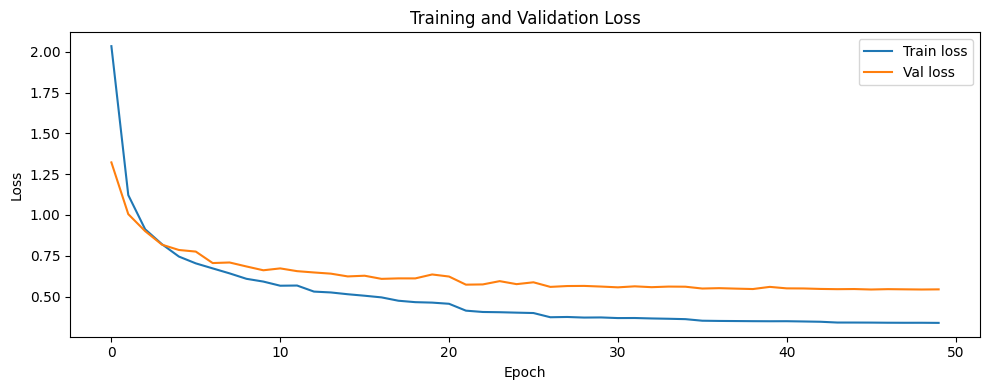

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Load the best head checkpoint for evaluation
head.load_state_dict(torch.load('emp_model_v2_head_best.pth'))
print('Best head loaded.')

Best head loaded.


In [14]:
def evaluate_accuracy(loader, split_name):
    head.eval()
    n_correct, n_total = 0, 0
    with torch.no_grad():
        for feats, targets in loader:
            feats, targets = feats.to(device), targets.to(device)
            _, preds = torch.max(head(feats), 1)
            n_correct += (preds == targets).sum().item()
            n_total += targets.size(0)
    acc = n_correct / n_total
    print(f'{split_name} accuracy: {acc:.4f} ({n_correct}/{n_total})')
    return acc

train_acc = evaluate_accuracy(train_loader, 'Train')
val_acc   = evaluate_accuracy(val_loader,   'Val')
test_acc  = evaluate_accuracy(test_loader,  'Test')

Train accuracy: 0.9055 (36140/39912)
Val accuracy: 0.8505 (8487/9979)
Test accuracy: 0.8499 (10601/12473)


In [ ]:
# Confusion matrix on the test set, ordered by emperor number ("01_AUGUSTUS" -> "53_SEVERUS II")

# Map each (prefix-stripped) class name back to its numeric folder prefix.
name_to_prefix = {
    re.sub(r'^\d+_', '', p.name): int(re.match(r'^(\d+)_', p.name).group(1))
    for p in Path(DATA_DIR).iterdir()
    if p.is_dir() and (p / 'side_a').exists()
}
class_order = sorted(range(num_classes), key=lambda i: name_to_prefix[idx_to_label[i]])
display_names = [f"{name_to_prefix[idx_to_label[i]]:02d}_{idx_to_label[i]}" for i in class_order]

head.eval()
cm = np.zeros((num_classes, num_classes), dtype=int)
with torch.no_grad():
    for feats, targets in test_loader:
        feats, targets = feats.to(device), targets.to(device)
        _, preds = torch.max(head(feats), 1)
        for t, p in zip(targets.cpu(), preds.cpu()):
            cm[t.item(), p.item()] += 1

# Reorder rows and columns so the matrix reads chronologically by emperor number
cm = cm[np.ix_(class_order, class_order)]

df_cm = pd.DataFrame(cm, index=display_names, columns=display_names)

plt.figure(figsize=(22, 18))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=display_names, yticklabels=display_names,
            annot_kws={'size': 7})
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title('Confusion Matrix (Test Set) — ordered by emperor number')
plt.tight_layout()
plt.show()


In [ ]:
# Confusion matrix as plain text — easy to copy and paste into an LLM chat.
# Reuses `cm`, `display_names`, `num_classes` from the previous cell (already ordered chronologically).
TOP_CONFUSIONS = 3  # how many wrong predictions to list per true class

total_correct = int(cm.diagonal().sum())
total = int(cm.sum())
print(f'Overall test accuracy: {total_correct}/{total} = {total_correct/total:.4f}')
print(f'Classes: {num_classes}\n')

row_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
order_worst_first = np.argsort(row_acc)  # worst-performing classes first — most useful for analysis

print('Per-class breakdown (sorted by accuracy, worst first):')
for i in order_worst_first:
    n_total = int(cm[i].sum())
    n_correct = int(cm[i, i])
    acc = n_correct / max(n_total, 1)
    print(f'\n{display_names[i]}: {n_correct}/{n_total} correct  acc={acc:.3f}')
    off = sorted(
        ((j, int(cm[i, j])) for j in range(num_classes) if j != i and cm[i, j] > 0),
        key=lambda x: -x[1],
    )
    if not off:
        print('  (no mistakes)')
        continue
    for j, count in off[:TOP_CONFUSIONS]:
        print(f'  -> predicted as {display_names[j]}: {count} ({count / max(n_total, 1):.1%})')
    remaining = sum(c for _, c in off[TOP_CONFUSIONS:])
    if remaining:
        print(f'  -> other classes: {remaining}')


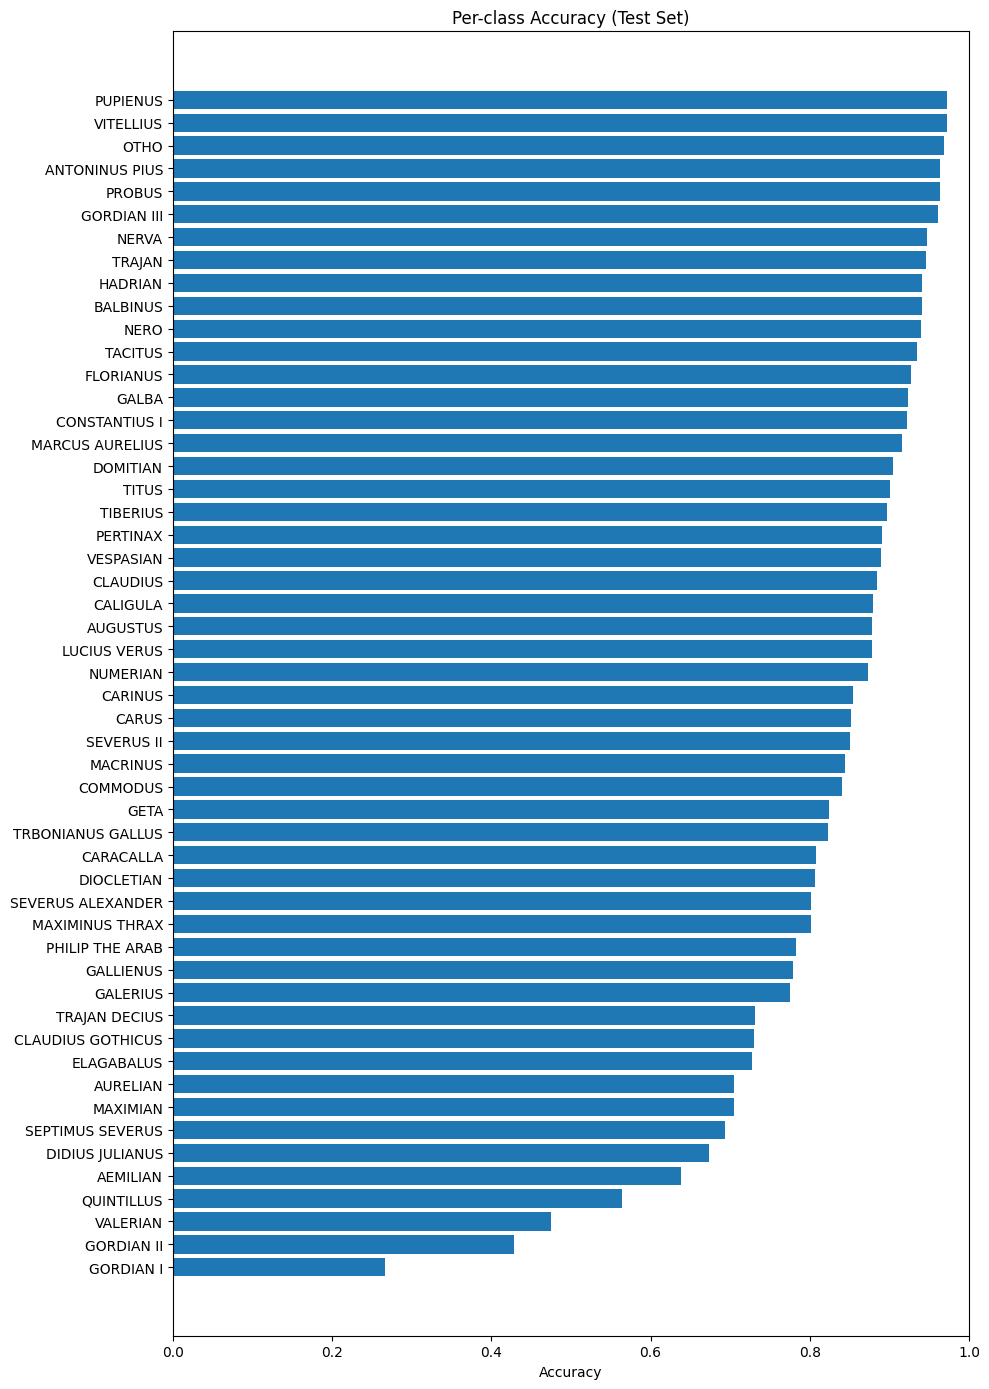

          Emperor  Accuracy
        GORDIAN I  0.266667
       GORDIAN II  0.428571
         VALERIAN  0.475410
       QUINTILLUS  0.564286
         AEMILIAN  0.638158
  DIDIUS JULIANUS  0.672956
 SEPTIMUS SEVERUS  0.693416
         MAXIMIAN  0.704433
         AURELIAN  0.704545
       ELAGABALUS  0.726994
CLAUDIUS GOTHICUS  0.730539
    TRAJAN DECIUS  0.730769
         GALERIUS  0.775148
        GALLIENUS  0.779141
  PHILIP THE ARAB  0.782609
  MAXIMINUS THRAX  0.801325
SEVERUS ALEXANDER  0.801948
       DIOCLETIAN  0.806604
        CARACALLA  0.807370
TRBONIANUS GALLUS  0.822581
             GETA  0.824691
         COMMODUS  0.840456
         MACRINUS  0.844633
       SEVERUS II  0.850000
            CARUS  0.851852
          CARINUS  0.854054
         NUMERIAN  0.873563
     LUCIUS VERUS  0.878049
         AUGUSTUS  0.878698
         CALIGULA  0.879747
         CLAUDIUS  0.884058
        VESPASIAN  0.889671
         PERTINAX  0.890323
         TIBERIUS  0.896970
            TITUS  0

In [16]:
# Per-class accuracy from the confusion matrix
per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
acc_df = pd.DataFrame({'Emperor': class_names, 'Accuracy': per_class_acc}).sort_values('Accuracy')

plt.figure(figsize=(10, 14))
plt.barh(acc_df['Emperor'], acc_df['Accuracy'])
plt.xlabel('Accuracy')
plt.title('Per-class Accuracy (Test Set)')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print(acc_df.to_string(index=False))